# Intro to Linear Regression

## Fernando Gutiérrez Canales
### Wed. 23 Sept. 2026

### We are going to start playing with linear regression. As you might know, the concept of linear regression is fairly simple: we have some data points plotted and we want to fit a straight line to those data points. How good or bad is the fit is going to be the core of the ```linear regression``` and ```least-squared``` concepts

In [20]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### We start with some data points. In this case we are gonna assume they are the age of some cute puppies (in years) in the x-axis and the number of visits to the vet on the y-axis

In [3]:
age = np.array([1,2,3,4,5,6,7,8,9,10])
number_of_visits = np.array([4.4, 10, 10, 14.4, 14, 14.4, 18.4, 18, 24.4, 22.4])

### Now we plot them

Text(0, 0.5, '# number of visits')

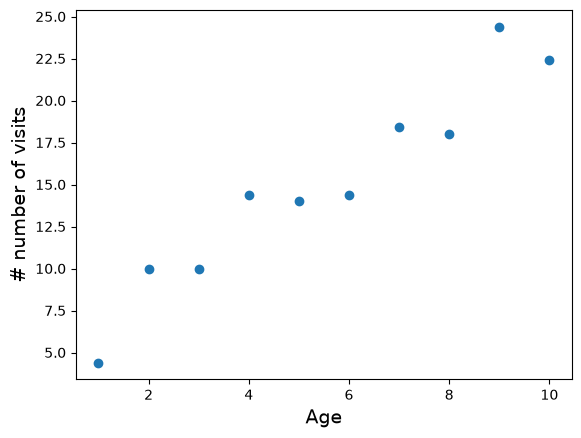

In [4]:
size = 14
plt.plot(age, number_of_visits, 'o')
plt.xlabel("Age", fontsize=size)
plt.ylabel("# number of visits", fontsize=size)

### As can be seen, this looks like a linear thing. However, how linear exactly? Let's try to fit a line. Since high-school we know that a straight line can be written as:

## $y = mx + b$

### where $m$ is the slope of the straight line and $b$ is the interception of the straight line with the 'y axis' whern 'x' is equal to 0. Let's guess some values for those parameters to create our first fit:

## $m = 2.2$
## $b = 3.2$

### and plot them:

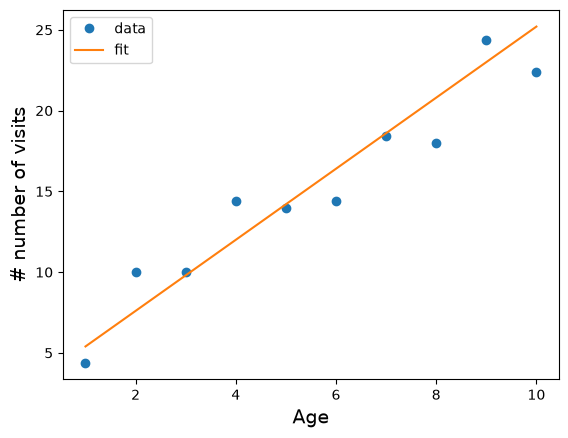

In [5]:
m_guess = 2.2
b_guess = 3.2
y = m_guess*age + b_guess # this is our guess fit
plt.plot(age, number_of_visits, 'o', label='data')
plt.plot(age, y, label='fit')
plt.xlabel("Age", fontsize=size)
plt.ylabel("# number of visits", fontsize=size)
plt.legend()

### As we see, the fit is not that bad. However, how do we know how bad or good it is? We need to measure how far away our fit is to the data points. To do that analytically, we are going to perform a least-squares test. We are interested in the following expresison, called the residual:

## $\rm res = \sum\limits_{n=1}^{N} \left( y_{data} - y_{fit} \right)$

### Of course we want to minimize the residual (i.e. the distance from the fit to the data points). To avoid having negative values that sometimes might cancel positive values out in the previous expression, we are goint to square it:

## $\rm res^{2} =  \sum\limits_{n=1}^{N} \left( y_{data} - y_{fit} \right)^{2}$

### Let's say as well that we are squaring the expression for $\rm res$ isntead of taking absolute values because it is easier to treat variables powered to a given number than absolute values, especially when it comes to derivatives (and derivatives are going to appear very soon when dealing with Linear Regression (spoiler!).

### Let's compute the square residual to the fit we just did!

In [18]:
# the number_of_visits is the 'y_data'
# the is the 'y_fit'

squared_res = 0
for i in range(len(y)):
    print("The residual for the points of index", i, "is:", (number_of_visits[i] - y[i])**2)
    squared_res = squared_res + (number_of_visits[i] - y[i])**2
    
print("If we add everything up, we obtain the total squared residual, that is:", squared_res)    

The residual for the points of index 0 is: 1.0
The residual for the points of index 1 is: 5.759999999999997
The residual for the points of index 2 is: 0.039999999999999716
The residual for the points of index 3 is: 5.760000000000002
The residual for the points of index 4 is: 0.039999999999999716
The residual for the points of index 5 is: 4.000000000000007
The residual for the points of index 6 is: 0.04000000000000114
The residual for the points of index 7 is: 7.840000000000004
The residual for the points of index 8 is: 1.959999999999996
The residual for the points of index 9 is: 7.840000000000004
If we add everything up, we obtain the total squared residual, that is: 34.280000000000015


In [19]:
# or more simply (since we are dealing with numpy arrays)
sq_res = np.sum((number_of_visits - y)**2)
print("The sum of squared residuals:", sq_res)

The sum of squared residuals: 34.280000000000015


### as can be seen, the squared residual is around 34. The best fit will be the fit that will give the least squared sum of residuals. How do we obtain such a fit? Well, in principle we could try different methods. For instance, we could obtain a lot of different combinations for $\rm m$ and $\rm b$ to see which one produces the least value of squared sum of residues. However, that will take 'ages' to finish. Therefore, according to the book ```Essential Math for Data Science``` we can use more or less 4 options:
- **Closed formula for $\rm m$ and $\rm b$**
- **Matix Inversion**
- **Matrix Decomposition**
- **Gradient Descent**
- **Stochastic Gradient Descent**

### 1. Closed formula

### 2. Matrix Inversion

### 3. Matrix Decomposition

### 4. Gradient Descent

### 5. Stochastic Gradient Descent

### Python has a nice library called ```sci-kit learn``` that has a module called ```Linear.Regression()```. We can use that to directly perform a Linear Regression to obtain the coefficients $\rm m$ and $\rm b$.

In [21]:
from sklearn.linear_model import LinearRegression

### before using the module imported above, we have to change the shape of our 'x' array, to convert it into a column vector. We do the following:

In [24]:
age_column_vector = age.reshape(-1, 1)

In [25]:
age_column_vector

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

### Now we use ```LinearRegression()``` with the new column vector and the old array for '$\rm y$'

In [26]:
fit = LinearRegression().fit(age_column_vector, number_of_visits)

### Now we obtain the coefficients:

In [28]:
m_fit_scikit = fit.coef_
print(m_fit_scikit)

[1.91030303]


In [30]:
b_fit_scikit = fit.intercept_
print(b_fit_scikit)

4.533333333333337
